In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def simulate_machine_cycle(mean_lifetime, replacement_time, replacement_cost, failure_cost):
    lifetime = np.random.exponential(mean_lifetime)
    if lifetime >= replacement_time:
        cost=replacement_cost
    else:
        cost=failure_cost
    cycle_time = min(lifetime, replacement_time)    
    return np.array([lifetime, cost, cycle_time])

In [11]:
def simulate_machine_cycles(n, mean_lifetime, replacement_time, replacement_cost, failure_cost):
    results = np.array([simulate_machine_cycle(mean_lifetime, replacement_time, replacement_cost, failure_cost) for _ in range(n)])
    average_cost = np.mean(results[:, 1])
    average_cycle_time = np.mean(results[:, 2])
    average_cost_per_time = average_cost / average_cycle_time
    return average_cost, average_cycle_time, average_cost_per_time


In [15]:
simulate_machine_cycles(10000, mean_lifetime=2000, replacement_time=1800, replacement_cost=800, failure_cost=2000)

(1498.76, 1195.1484996269128, 1.2540366326593433)

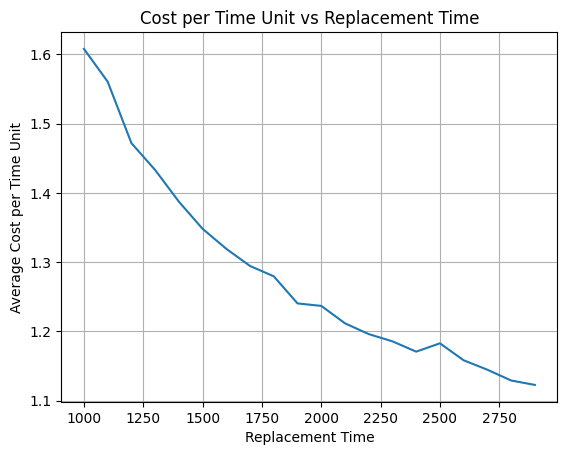

In [18]:
rtimes=np.arange(1000, 3000, 100)
costs_per_time = [simulate_machine_cycles(20000, mean_lifetime=2000, replacement_time=rt, replacement_cost=800, failure_cost=2000)[2] for rt in rtimes]
plt.plot(rtimes, costs_per_time)
plt.xlabel('Replacement Time')
plt.ylabel('Average Cost per Time Unit')
plt.title('Cost per Time Unit vs Replacement Time')
plt.grid()
plt.show()